In [2]:
import numpy as np
import pandas as pd
import os
from PIL import Image
from pathlib import Path
import sklearn
from sklearn.preprocessing import MaxAbsScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import randint, uniform
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing

### Raw data

In [3]:
# Loading data

star_folder_dir = "data//star"
galaxy_folder_dir = "data//galaxy"
star_images = Path(star_folder_dir).glob("*")
galaxy_images = Path(galaxy_folder_dir).glob("*")
star_list = []
for image in star_images:
    img = Image.open(image).convert("L")
    star_list.append(np.array(img).reshape(-1))
star_df = pd.DataFrame(star_list)
galaxy_list = []
for image in galaxy_images:
    img = Image.open(image).convert("L")
    galaxy_list.append(np.array(img).reshape(-1))
galaxy_df = pd.DataFrame(galaxy_list)

# Adding labels
star_df["Type"] = 1
galaxy_df["Type"] = 0

# Combine and shuffle dataframes
df = pd.concat([star_df, galaxy_df]).sample(frac=1, ignore_index=True, random_state=101290365)
df.head()

# Convert into X and y matrices/vectors:
X = df.drop("Type", axis=1)
y = pd.DataFrame(df["Type"])
X.shape, y.shape

# Standardizing Data:
transformer = MaxAbsScaler()
X = pd.DataFrame(transformer.fit_transform(X))

np.save('X.npy', X)
np.save('y.npy', y)

### Preprocessing with PCA: from the initial data exploration, we choose number of component = 1282.

In [4]:
if os.path.exists('X_PCA.npy'):
  X_PCA = np.load('X_PCA.npy')
else:
  pca_true_transform = PCA(n_components=1282)
  X_PCA = pca_true_transform.fit_transform(X.to_numpy())
  np.save('X_PCA.npy', X_PCA)

print(X_PCA.shape)

(3986, 1282)


# Random forest implementation

### Split Data

In [6]:
# Split X_PCA and y
X_PCA_train, X_PCA_test, y_train, y_test = train_test_split(X_PCA, y, test_size=0.2, random_state=42)

print("Shape of X_PCA_train:", X_PCA_train.shape)
print("Shape of X_PCA_test:", X_PCA_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_PCA_train: (3188, 1282)
Shape of X_PCA_test: (798, 1282)
Shape of y_train: (3188, 1)
Shape of y_test: (798, 1)


## Initial model: a simple (regular) RF model

### Random Forest on PCA Data


In [ ]:
model_RF_PCA_final = RandomForestClassifier(n_estimators=100, criterion='entropy', min_samples_leaf=2, random_state=42)
model_RF_PCA_final.fit(X_PCA_train, y_train.values.ravel())
y_train_pred = model_RF_PCA_final.predict(X_PCA_train)
y_pred_1 = model_RF_PCA_final.predict(X_PCA_test)

print(f"  Training Accuracy: {sklearn.metrics.accuracy_score(y_train, y_train_pred):.4f}")
print(f"  Testing Accuracy: {sklearn.metrics.accuracy_score(y_test, y_pred_1):.4f}")
print("Classification Report (PCA):\n", classification_report(y_test, y_pred_1, zero_division=0))
print("Confusion Matrix (PCA):\n", confusion_matrix(y_test, y_pred_1))

  Training Accuracy: 1.0000
  Testing Accuracy: 0.7757
Classification Report (PCA):
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       179
           1       0.78      1.00      0.87       619

    accuracy                           0.78       798
   macro avg       0.39      0.50      0.44       798
weighted avg       0.60      0.78      0.68       798

Confusion Matrix (PCA):
 [[  0 179]
 [  0 619]]


Although the accuracies seem to be high, a likely underlying reason is that since the dataset is imbalanced, the model simply keeps predicting class label = 1 (star) all the time, as we can see in the classification report and the confusion matrix.

### Analyze Class Distribution


In [28]:
print("Class distribution in y_train:")
print(y_train.value_counts())

print("\nClass distribution in y_test:")
print(y_test.value_counts())

Class distribution in y_train:
Type
1       2425
0        763
Name: count, dtype: int64

Class distribution in y_test:
Type
1       619
0       179
Name: count, dtype: int64


## Train Models with Class Weighting


We retrain the Random Forest classifiers for the preprocessed dataset by using the `BalancedRandomForestClassifier` method.

### New training model with balance


This time we use stratified K-fold to choose the best set of hyperparameter.

In [10]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score

n_estimators_list = [200, 400]
max_depth_list = [None, 10, 20]
min_samples_split_list = [2, 5, 10]
min_samples_leaf_list = [1, 2, 4]

configs = []
mean_accuracies = []

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for n_est in n_estimators_list:
    for md in max_depth_list:
        for mss in min_samples_split_list:
            for msl in min_samples_leaf_list:
                fold_accuracies = []
                print(f"\nNow fitting: n_est = {n_est}, max_depth = {md}, mss = {mss}, msl = {msl} ")

                # Inner CV loop
                for train_index, val_index in skf.split(X_PCA_train, y_train):
                    X_train_fold, X_val_fold = X_PCA_train[train_index], X_PCA_train[val_index]
                    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

                    brf = BalancedRandomForestClassifier(
                        n_estimators=n_est,
                        max_depth=md,
                        min_samples_split=mss,
                        min_samples_leaf=msl,
                        criterion='entropy',
                        n_jobs=-1,
                        random_state=42
                    )
                    brf.fit(X_train_fold, y_train_fold.values.ravel())
                    y_val_pred = brf.predict(X_val_fold)
                    acc = accuracy_score(y_val_fold, y_val_pred)
                    fold_accuracies.append(acc)
                    # Print classification report for each fold:
                    print(classification_report(y_val_fold, y_val_pred))

                mean_acc = np.mean(fold_accuracies)
                configs.append({
                    "n_estimators": n_est,
                    "max_depth": md,
                    "min_samples_split": mss,
                    "min_samples_leaf": msl
                })
                print("Mean accuracy:", mean_acc)
                mean_accuracies.append(mean_acc)

# Select best configuration
best_idx = int(np.argmax(mean_accuracies))
best_params = configs[best_idx]
best_cv_acc = mean_accuracies[best_idx]

print("Best params:", best_params)
print("Best cross-validation accuracy:", best_cv_acc)


Now fitting: n_est = 200, max_depth = None, mss = 2, msl = 1 
              precision    recall  f1-score   support

           0       0.54      0.21      0.30       153
           1       0.79      0.94      0.86       485

    accuracy                           0.77       638
   macro avg       0.67      0.58      0.58       638
weighted avg       0.73      0.77      0.73       638

              precision    recall  f1-score   support

           0       0.47      0.16      0.24       153
           1       0.78      0.94      0.85       485

    accuracy                           0.76       638
   macro avg       0.63      0.55      0.54       638
weighted avg       0.71      0.76      0.71       638

              precision    recall  f1-score   support

           0       0.53      0.16      0.24       153
           1       0.78      0.96      0.86       485

    accuracy                           0.76       638
   macro avg       0.66      0.56      0.55       638
weighted av

### Fitting the final model and evaluation

In [31]:
brf = BalancedRandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=2,
    criterion='entropy',
    n_jobs=-1,
    random_state=42
)
brf.fit(X_PCA_train, y_train.values.ravel())
y_pred_2 = brf.predict(X_PCA_test)
acc = accuracy_score(y_test, y_pred_2)

print("Accuracy:", acc)
print("Classification Report:\n", classification_report(y_test, y_pred_2))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_2))

Accuracy: 0.7669172932330827
Classification Report:
               precision    recall  f1-score   support

           0       0.42      0.10      0.16       179
           1       0.79      0.96      0.86       619

    accuracy                           0.77       798
   macro avg       0.60      0.53      0.51       798
weighted avg       0.70      0.77      0.71       798

Confusion Matrix:
 [[ 18 161]
 [ 25 594]]


In [33]:
# Predict probabilities for class 1
y_proba = brf.predict_proba(X_PCA_test)[:, 1]

# Set a lower threshold
threshold = 0.55
y_pred_3 = (y_proba >= threshold).astype(int)

acc = accuracy_score(y_test, y_pred_3)
print("Accuracy:", acc)

print("Classification Report:")
print(classification_report(y_test, y_pred_3))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_3))

Accuracy: 0.7593984962406015
Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.57      0.52       179
           1       0.87      0.81      0.84       619

    accuracy                           0.76       798
   macro avg       0.67      0.69      0.68       798
weighted avg       0.78      0.76      0.77       798

Confusion Matrix:
[[102  77]
 [115 504]]


### Visualizing balancing improvement



In [34]:
def get_metrics(y_true, y_pred, model_name, weighted=False):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    metrics = {
        'model': model_name,
        'weighted': weighted,
        'accuracy': report['accuracy'],
        'precision_0': report['0']['precision'],
        'recall_0': report['0']['recall'],
        'f1_0': report['0']['f1-score'],
        'precision_1': report['1']['precision'],
        'recall_1': report['1']['recall'],
        'f1_1': report['1']['f1-score'],
    }
    return metrics

# Collect metrics for all models
all_metrics = []

# Classic Model
all_metrics.append(get_metrics(y_test, y_pred_1, 'Classic Model'))

# Balanced Model - Normal Threshold
all_metrics.append(get_metrics(y_test, y_pred_2, 'Balanced Model - Normal Threshold'))

# Balanced Model - High Threshold
all_metrics.append(get_metrics(y_test, y_pred_3, 'Balanced Model - High Threshold'))

# Convert to DataFrame for better display
metrics_df = pd.DataFrame(all_metrics)

# Display the metrics
print("\n--- Performance Metrics Comparison ---")
print(metrics_df.to_string())



--- Performance Metrics Comparison ---
                               model  weighted  accuracy  precision_0  recall_0      f1_0  precision_1  recall_1      f1_1
0                      Classic Model     False  0.775689     0.000000  0.000000  0.000000     0.775689  1.000000  0.873677
1  Balanced Model - Normal Threshold     False  0.766917     0.418605  0.100559  0.162162     0.786755  0.959612  0.864629
2    Balanced Model - High Threshold     False  0.759398     0.470046  0.569832  0.515152     0.867470  0.814216  0.840000


### Visualize Performance Metrics

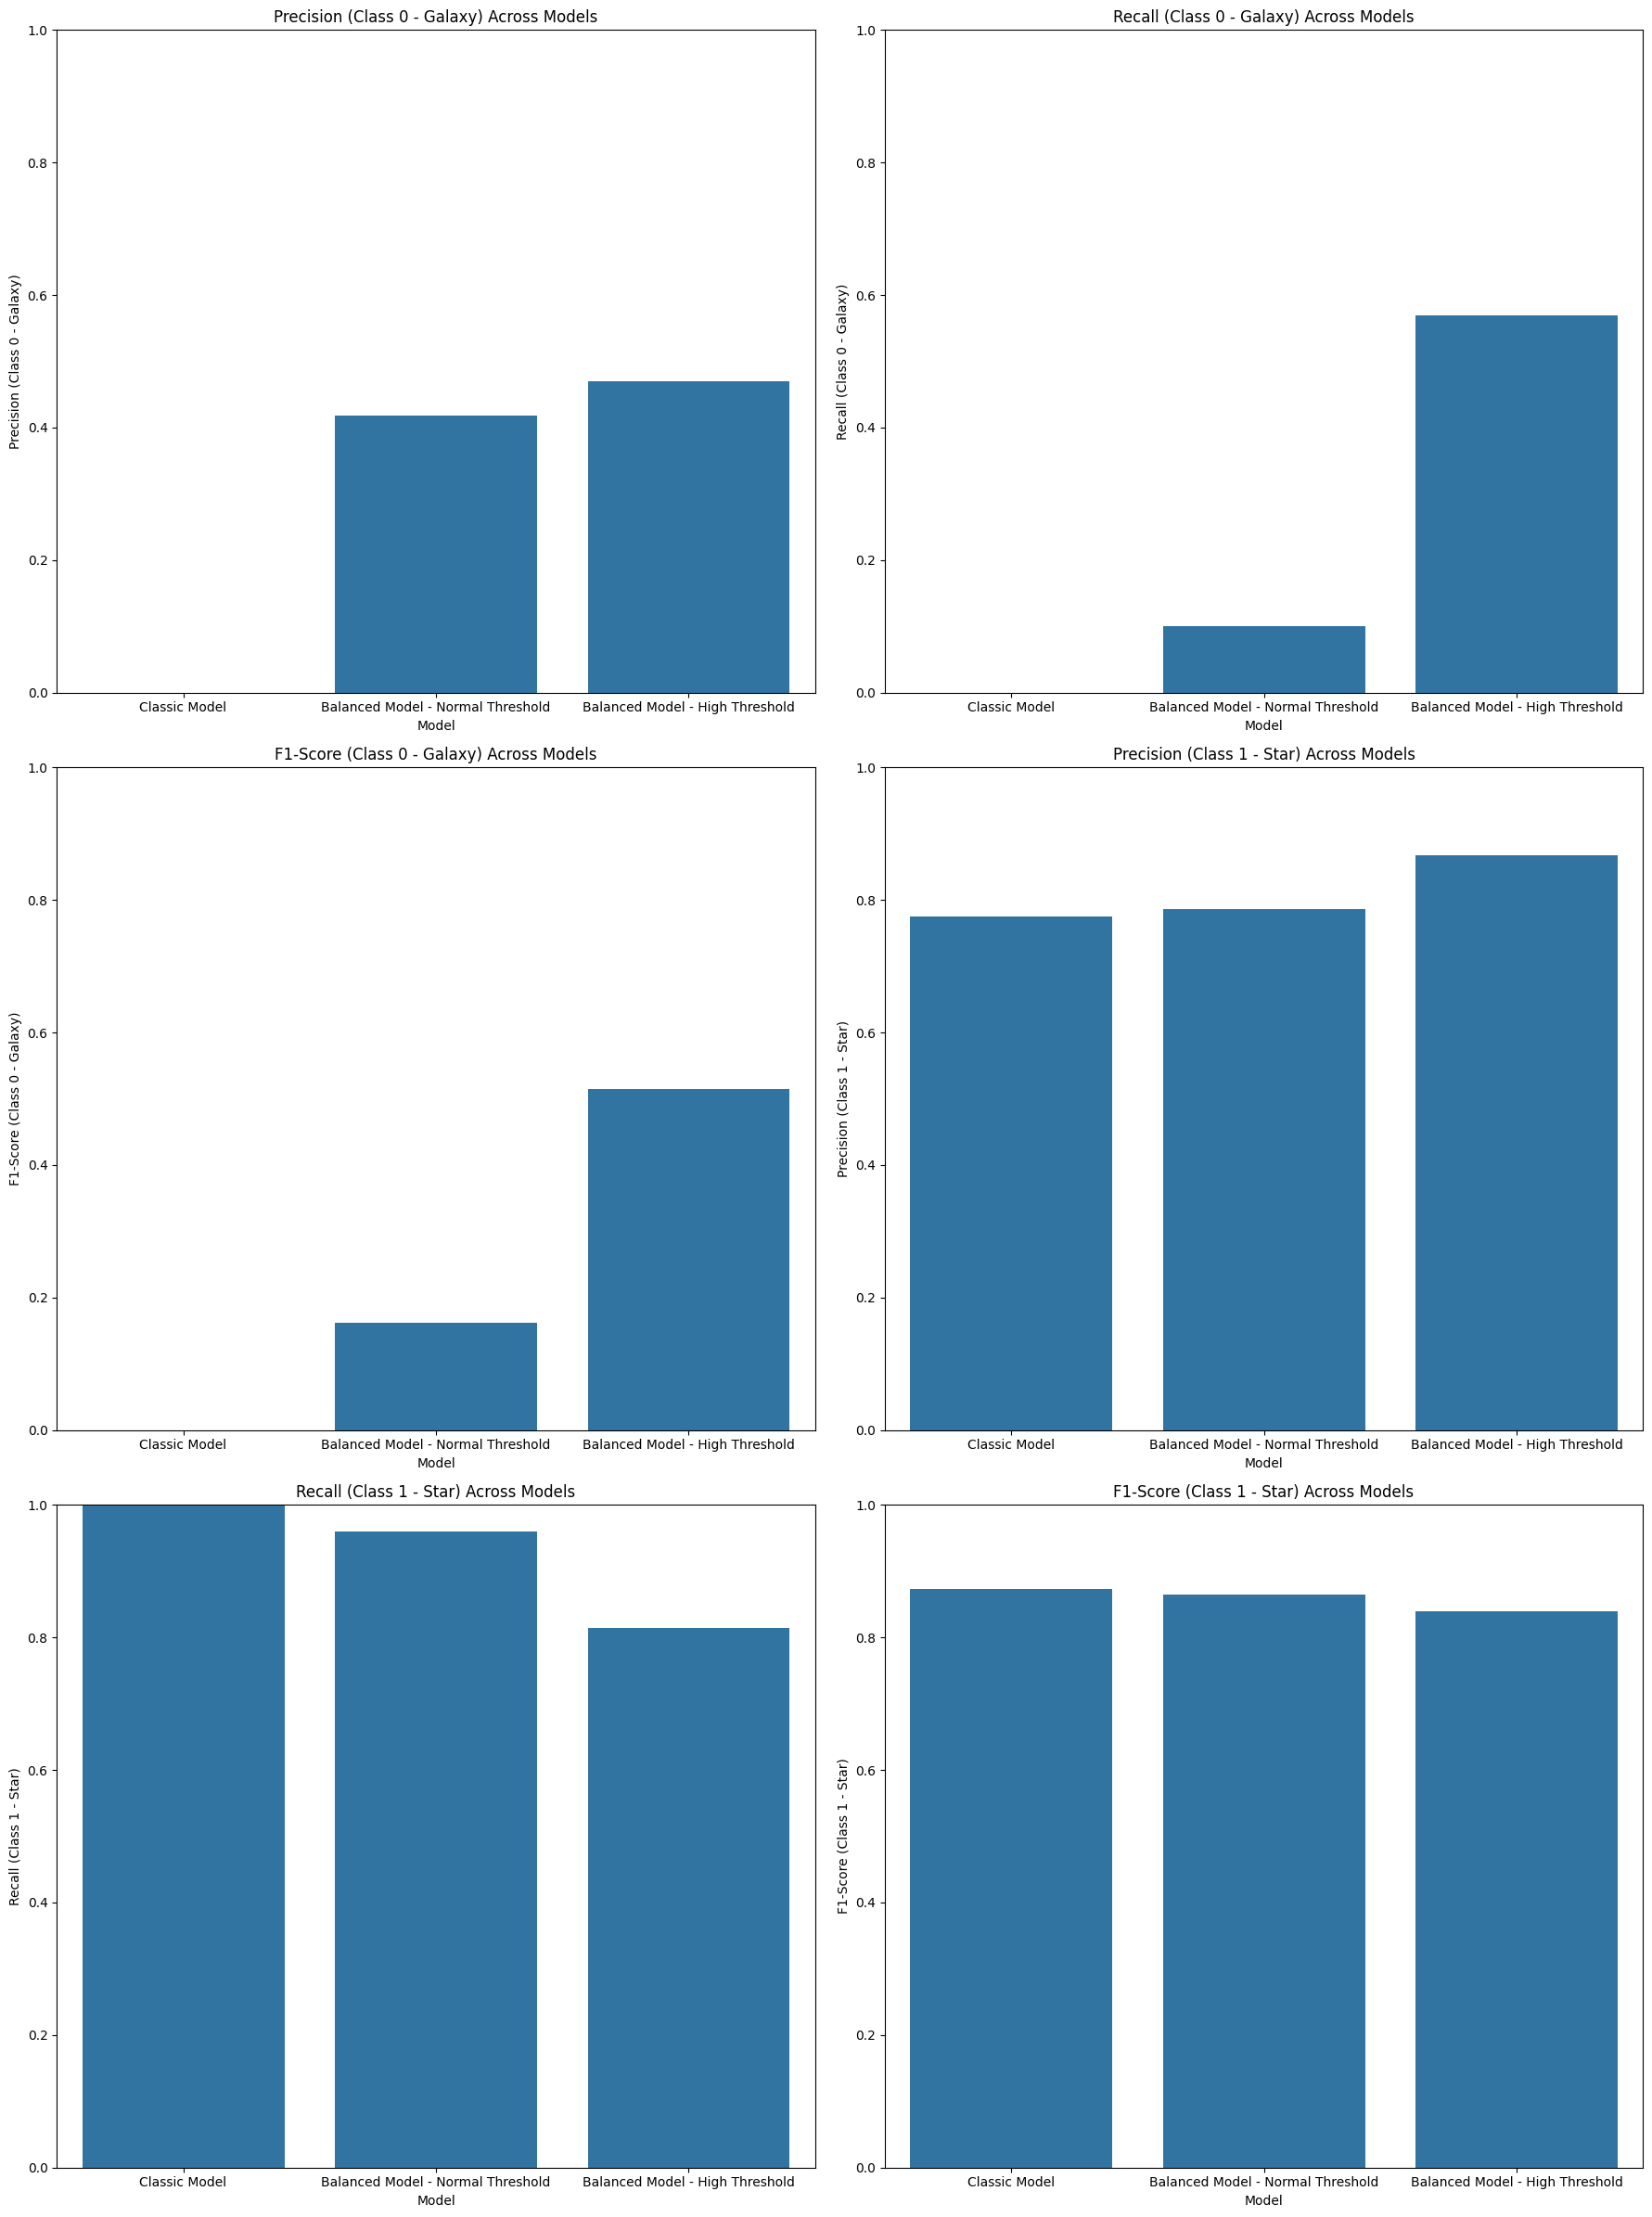

Visualizations of performance metrics generated.


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics_to_plot = {
    'precision_0': 'Precision (Class 0 - Galaxy)',
    'recall_0': 'Recall (Class 0 - Galaxy)',
    'f1_0': 'F1-Score (Class 0 - Galaxy)',
    'precision_1': 'Precision (Class 1 - Star)',
    'recall_1': 'Recall (Class 1 - Star)',
    'f1_1': 'F1-Score (Class 1 - Star)'
}

plt.figure(figsize=(18, 24))
plot_num = 1

for metric_col, title_text in metrics_to_plot.items():
    plt.subplot(3, 2, plot_num)
    sns.barplot(x='model', y=metric_col, data=metrics_df)
    plt.title(f'{title_text} Across Models')
    plt.xlabel('Model')
    plt.ylabel(title_text)
    plt.ylim(0, 1) # Metrics are between 0 and 1
    plot_num += 1

plt.tight_layout()
plt.show()

print("Visualizations of performance metrics generated.")